# TFM - Clasificación de frutas con Machine Learning

## Pipeline clásico con KNN sobre dataset completo

En este notebook se escala el pipeline clásico previamente validado con una muestra reducida (`sample_100`) al dataset completo.

El pipeline mantiene la misma lógica técnica:

1. Lectura de imágenes con OpenCV.
2. Extracción de características visuales:
   - Histograma RGB.
   - HOG.
   - LBP.
3. Concatenación de características en un único vector.
4. Escalado con StandardScaler.
5. Reducción de dimensionalidad con PCA conservando el 95% de la varianza.
6. Entrenamiento de un modelo de Machine Learning con KNN.
7. Evaluación mediante:
   - Accuracy.
   - F1 macro.
   - Classification report.
   - Matriz de confusión.

El objetivo de este notebook no es rediseñar el pipeline, sino escalarlo de forma controlada al conjunto completo de imágenes.

------
------

## Bloque 1 - Imports y configuración inicial

En este bloque se importan las librerías necesarias para desarrollar el pipeline clásico de Machine Learning aplicado a la clasificación de frutas.

Se incluyen librerías para:

* gestionar rutas y archivos del proyecto;
* trabajar con datos en formato tabla y arrays numéricos;
* leer y procesar imágenes con OpenCV;
* visualizar resultados;
* dividir los datos en entrenamiento y prueba;
* escalar características;
* aplicar PCA;
* entrenar el modelo KNN;
* evaluar el rendimiento del modelo;
* guardar objetos intermedios o modelos entrenados.


In [1]:
# =========================
# BLOQUE 1: IMPORTS Y CONFIGURACIÓN INICIAL
# =========================

from pathlib import Path  # Permite trabajar con rutas de carpetas y archivos de forma más clara y compatible
import os                 # Permite interactuar con el sistema operativo si fuera necesario
import time               # Permite medir tiempos de ejecución
import numpy as np         # Permite trabajar con arrays y operaciones numéricas
import pandas as pd        # Permite crear tablas y analizar datos
import cv2                 # OpenCV: permite leer y procesar imágenes
import matplotlib.pyplot as plt  # Permite crear gráficos y visualizaciones

# Machine Learning
# División del dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# StandardScaler normaliza las características para que tengan una escala comparable.
# Esto es especialmente importante en KNN, porque el modelo calcula distancias.
from sklearn.preprocessing import StandardScaler

# PCA reduce la dimensionalidad manteniendo la mayor parte de la información.
# En este caso conservaremos el 95% de la varianza.
from sklearn.decomposition import PCA

# KNN será el modelo de Machine Learning utilizado para clasificar las frutas.
# Clasifica una imagen según las clases de sus vecinos más cercanos.
from sklearn.neighbors import KNeighborsClassifier

# Métricas para evaluar el rendimiento del modelo
from sklearn.metrics import (
    accuracy_score,          # Porcentaje global de aciertos
    f1_score,                # Métrica útil cuando hay clases desbalanceadas
    classification_report,   # Informe detallado por clase: precision, recall y F1
    confusion_matrix,        # Tabla de aciertos y errores entre clases
    ConfusionMatrixDisplay   # Visualización gráfica de la matriz de confusión
)

# Permite guardar objetos de Python, como modelos, scaler, PCA o arrays procesados
import joblib

## Bloque 2 - Definición de rutas del proyecto

En este bloque se definen las rutas principales del proyecto TFM.  
El objetivo es centralizar en variables las carpetas y archivos importantes para evitar escribir rutas manuales durante el notebook.

Se identifican:

- la carpeta raíz del proyecto;
- la carpeta de datos originales;
- la carpeta `archive`, donde se encuentra el dataset original;
- el archivo `dataset_maestro.csv`, que será la base principal del notebook;
- las carpetas `outputs` y `models`, donde se guardarán resultados y modelos.

In [2]:
# =========================
# BLOQUE 2: RUTAS DEL PROYECTO
# =========================

# CURRENT_DIR indica desde qué carpeta se está ejecutando actualmente el notebook.
# Esto nos ayuda a saber si VS Code está ejecutando desde TFM/ o desde TFM/notebooks/.
CURRENT_DIR = Path.cwd()

# PROJECT_DIR representa la carpeta raíz del proyecto.
# En nuestro caso debería apuntar a la carpeta TFM/.
# Si el notebook se ejecuta desde notebooks/, subimos un nivel con .parent.
if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

# DATA_DIR apunta a la carpeta principal donde están los datos del proyecto.
DATA_DIR = PROJECT_DIR / "data"

# RAW_DIR apunta a los datos originales.
# Aquí está el CSV original de Javier y la carpeta archive.
RAW_DIR = DATA_DIR / "raw"

# ARCHIVE_DIR apunta a la carpeta donde están las imágenes/dataset original.
ARCHIVE_DIR = RAW_DIR / "archive"

# PROCESSED_DIR apunta a los datos ya procesados o depurados.
PROCESSED_DIR = DATA_DIR / "processed"

# SAMPLE_100_DIR apunta a la muestra usada en la validación anterior.
SAMPLE_100_DIR = DATA_DIR / "sample_100"

# RAW_DATASET_CSV es el CSV original de Javier.
# Lo dejamos localizado, pero no será la fuente principal del notebook 02.
RAW_DATASET_CSV = RAW_DIR / "raw_dataset.csv"

# DATASET_MAESTRO_CSV es el CSV limpio creado por nosotros.
# Este será la fuente principal para trabajar con el dataset completo.
DATASET_MAESTRO_CSV = PROCESSED_DIR / "dataset_maestro.csv"

# SAMPLE_100_CSV es el CSV usado en el notebook 01.
# Lo dejamos como referencia, pero no será la base de este notebook.
SAMPLE_100_CSV = SAMPLE_100_DIR / "sample_100.csv"

# OUTPUTS_DIR será la carpeta donde guardaremos resultados:
# métricas, tablas, reportes o matrices.
OUTPUTS_DIR = PROJECT_DIR / "outputs"

# MODELS_DIR será la carpeta donde guardaremos objetos del modelo:
# scaler, PCA, KNN entrenado, etc.
MODELS_DIR = PROJECT_DIR / "models"

# FEATURES_DIR será la carpeta donde guardaremos características extraídas,
# matrices escaladas, matrices PCA y particiones train/test.
FEATURES_DIR = PROCESSED_DIR / "features"

# Archivos de características extraídas
X_FEATURES_PATH = FEATURES_DIR / "X_rgb_hog_lbp_8206_float32.npy"
METADATA_FEATURES_PATH = FEATURES_DIR / "metadata_rgb_hog_lbp.csv"
ERRORS_FEATURES_PATH = FEATURES_DIR / "errores_extraccion.csv"

# Archivo con la división train/test
SPLIT_PATH = FEATURES_DIR / "split_train_test_indices_80_20.npz"

# Archivos generados tras StandardScaler
X_TRAIN_SCALED_PATH = FEATURES_DIR / "X_train_scaled_float32.npy"
X_TEST_SCALED_PATH = FEATURES_DIR / "X_test_scaled_float32.npy"

# Archivos generados tras PCA
X_TRAIN_PCA_PATH = FEATURES_DIR / "X_train_pca_1506_float32.npy"
X_TEST_PCA_PATH = FEATURES_DIR / "X_test_pca_1506_float32.npy"

# Modelos guardados
SCALER_PATH = MODELS_DIR / "standard_scaler_rgb_hog_lbp.joblib"
PCA_PATH = MODELS_DIR / "incremental_pca_1506_rgb_hog_lbp.joblib"

# Creamos las carpetas de salida si no existen.
# Si ya existen, no ocurre nada gracias a exist_ok=True.
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# Mostramos las rutas para comprobar visualmente que apuntan bien.
print("CURRENT_DIR:", CURRENT_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("RAW_DIR:", RAW_DIR)
print("ARCHIVE_DIR:", ARCHIVE_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("SAMPLE_100_DIR:", SAMPLE_100_DIR)
print("RAW_DATASET_CSV:", RAW_DATASET_CSV)
print("DATASET_MAESTRO_CSV:", DATASET_MAESTRO_CSV)
print("SAMPLE_100_CSV:", SAMPLE_100_CSV)
print("OUTPUTS_DIR:", OUTPUTS_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("FEATURES_DIR:", FEATURES_DIR)
print("X_TRAIN_PCA_PATH:", X_TRAIN_PCA_PATH)
print("X_TEST_PCA_PATH:", X_TEST_PCA_PATH)
print("SPLIT_PATH:", SPLIT_PATH)
print("SCALER_PATH:", SCALER_PATH)
print("PCA_PATH:", PCA_PATH)

CURRENT_DIR: /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/03_Machine_Learning
PROJECT_DIR: /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/03_Machine_Learning
DATA_DIR: /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/03_Machine_Learning/data
RAW_DIR: /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/03_Machine_Learning/data/raw
ARCHIVE_DIR: /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/03_Machine_Learning/data/raw/archive
PROCESSED_DIR: /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENT

## Bloque 3 - Comprobación de rutas

En este bloque se comprueba que las rutas definidas anteriormente existen realmente dentro del proyecto.

El objetivo es validar que el notebook puede localizar correctamente:

- la carpeta principal del proyecto;
- las carpetas de datos;
- la carpeta `archive`;
- el CSV original `raw_dataset.csv`;
- el CSV principal `dataset_maestro.csv`;
- el CSV de validación `sample_100.csv`;
- las carpetas `outputs` y `models`.

Esta comprobación evita errores posteriores al cargar datos o guardar resultados.

In [10]:
# =========================
# BLOQUE 3: COMPROBACIÓN DE RUTAS
# =========================

# Creamos un diccionario con las rutas importantes del proyecto.
# La clave es el nombre de la variable y el valor es la ruta correspondiente.
rutas_a_comprobar = {
    "PROJECT_DIR": PROJECT_DIR,
    "DATA_DIR": DATA_DIR,
    "RAW_DIR": RAW_DIR,
    "ARCHIVE_DIR": ARCHIVE_DIR,
    "PROCESSED_DIR": PROCESSED_DIR,
    "SAMPLE_100_DIR": SAMPLE_100_DIR,
    "RAW_DATASET_CSV": RAW_DATASET_CSV,
    "DATASET_MAESTRO_CSV": DATASET_MAESTRO_CSV,
    "SAMPLE_100_CSV": SAMPLE_100_CSV,
    "OUTPUTS_DIR": OUTPUTS_DIR,
    "MODELS_DIR": MODELS_DIR
}

# Recorremos cada ruta y comprobamos si existe.
# ruta.exists() devuelve:
# True  -> la ruta existe
# False -> la ruta no existe o está mal definida
for nombre, ruta in rutas_a_comprobar.items():
    print(f"{nombre}: {ruta.exists()} -> {ruta}")

PROJECT_DIR: True -> /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/03_Machine_Learning
DATA_DIR: True -> /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/03_Machine_Learning/data
RAW_DIR: True -> /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/03_Machine_Learning/data/raw
ARCHIVE_DIR: True -> /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/03_Machine_Learning/data/raw/archive
PROCESSED_DIR: True -> /Users/fcofraguas/Desktop/Master Pontia/Master Pontia/Visión artificial/proyecto_vision_artificial/00_ENTREGABLES/3.Archivos_ejecutables/03_Machine_Learning/data/processed
SAMPLE_100_DIR: True -> /Users/fcofraguas/Desktop/Master Pontia/

## Bloque 4 - Carga inicial del dataset maestro

En este bloque se carga el archivo `dataset_maestro.csv`, que será la base principal para trabajar con el dataset completo.

Este CSV no contiene todavía los vectores de características de las imágenes.  
Su función es actuar como tabla maestra del dataset, indicando qué imágenes existen y a qué clase o fruta pertenecen.

Antes de iniciar la extracción de características, se revisan sus dimensiones, columnas y primeras filas.

In [7]:
# =========================
# BLOQUE 4: CARGA INICIAL DEL DATASET MAESTRO
# =========================

# Cargamos el CSV maestro creado previamente.
# Este archivo será la base principal para trabajar con el dataset completo.
df_maestro = pd.read_csv(DATASET_MAESTRO_CSV)

# Mostramos el tamaño del DataFrame.
# shape devuelve: (número de filas, número de columnas)
print("Dimensiones del dataset maestro:", df_maestro.shape)

# Mostramos los nombres de las columnas.
print("\nColumnas del dataset maestro:")
print(df_maestro.columns.tolist())

# Visualizamos las primeras filas para entender su estructura.
df_maestro.head()

Dimensiones del dataset maestro: (70549, 4)

Columnas del dataset maestro:
['Unnamed: 0', '0', 'fruta', 'percent']


,Unnamed: 0,0,fruta,percent
0,0,Apple/Apple A/Apple 1.png,Apple,15.854229
1,1,Apple/Apple A/Apple 10.png,Apple,15.854229
2,2,Apple/Apple A/Apple 100.png,Apple,15.854229
3,3,Apple/Apple A/Apple 101.png,Apple,15.854229
4,4,Apple/Apple A/Apple 102.png,Apple,15.854229


## Bloque 5 - Limpieza básica de columnas

En este bloque se realiza una limpieza inicial del `dataset_maestro`.

El objetivo es eliminar columnas que actúan como índices antiguos y renombrar las columnas importantes con nombres más interpretables.

Esta limpieza se aplica sobre el DataFrame cargado en memoria, sin modificar  el archivo CSV original.

In [8]:
# =========================
# BLOQUE 5: LIMPIEZA BÁSICA DE COLUMNAS
# =========================

# Creamos una copia del DataFrame original para no modificar directamente df_maestro.
# Esto permite mantener una versión inicial intacta por si necesitamos revisarla.
df = df_maestro.copy()

# Eliminamos la columna "Unnamed: 0".
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Renombramos columnas para que sean más intuitivas.
# La columna "0" contiene la referencia/ruta de la imagen.
# La columna "fruta" contiene la clase objetivo.
df = df.rename(columns={
    "0": "ruta_imagen",
    "fruta": "clase"
})

# Mostramos las columnas resultantes para comprobar el cambio.
print("Columnas después de la limpieza:")
print(df.columns.tolist())

# Mostramos las primeras filas del DataFrame limpio.
df.sample(5)

Columnas después de la limpieza:
['ruta_imagen', 'clase', 'percent']


,ruta_imagen,clase,percent
39381,Kiwi/Total Number of Kiwi fruit/Kiwi002168.png,Kiwi,11.998753
32211,Guava/guava total final/Guava01204.png,Guava,27.921019
35732,Guava/guava total final/Guava0767.png,Guava,27.921019
64887,Pomegranate/Pomegranet001678.png,Pomegranate,3.071624
70277,muskmelon/Muskmelon 00754.png,muskmelon,2.945471


## Bloque 6 - Validación básica del dataset limpio

En este bloque se valida la estructura del DataFrame limpio antes de iniciar el procesamiento de imágenes.

El objetivo es comprobar que el dataset contiene rutas de imágenes, clases asociadas y la columna `percent`, que representa el peso de cada imagen.

También se revisan valores nulos, rutas duplicadas y la distribución de imágenes por clase.

In [9]:
# =========================
# BLOQUE 6: VALIDACIÓN BÁSICA DEL DATASET LIMPIO
# =========================

# Mostramos las dimensiones del DataFrame limpio.
# Esto indica cuántas imágenes/registros y columnas tenemos.
print("Dimensiones del DataFrame limpio:", df.shape)

# Comprobamos si existen valores nulos por columna.
# Los nulos podrían indicar problemas en rutas, clases o pesos.
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Comprobamos si existen rutas de imagen duplicadas.
# Una ruta duplicada significaría que una misma imagen aparece más de una vez.
duplicados_ruta = df["ruta_imagen"].duplicated().sum()
print("\nRutas de imagen duplicadas:", duplicados_ruta)

# Comprobamos cuántas clases/frutas diferentes hay.
n_clases = df["clase"].nunique()
print("\nNúmero de clases/frutas:", n_clases)

# Mostramos la cantidad de imágenes por clase.
# Esto permite ver si el dataset está balanceado o desbalanceado.
conteo_clases = df["clase"].value_counts().sort_index()

print("\nCantidad de imágenes por clase:")
print(conteo_clases)

Dimensiones del DataFrame limpio: (70549, 3)

Valores nulos por columna:
ruta_imagen    0
clase          0
percent        0
dtype: int64

Rutas de imagen duplicadas: 0

Número de clases/frutas: 15

Cantidad de imágenes por clase:
clase
Apple          11185
Banana          3027
Carambola       2080
Guava          19698
Kiwi            8465
Mango           4154
Orange          3012
Peach           2629
Pear            3012
Persimmon       2072
Pitaya          2501
Plum            2298
Pomegranate     2167
Tomatoes        2171
muskmelon       2078
Name: count, dtype: int64


## Bloque 7 - Validación inicial de rutas de imágenes

En este bloque se revisa cómo está construida la columna `ruta_imagen` del `dataset_maestro`.

El objetivo es comprobar si las rutas de las imágenes apuntan correctamente a archivos existentes dentro del proyecto.

Esta validación es necesaria antes de aplicar OpenCV, ya que el modelo solo podrá procesar imágenes que puedan localizarse correctamente en disco.

In [10]:
# =========================
# BLOQUE 7: VALIDACIÓN INICIAL DE RUTAS DE IMÁGENES
# =========================

# Mostramos algunas rutas tal como vienen en el dataset maestro.
# Esto nos permite entender si son rutas relativas, absolutas o nombres de archivo.
print("Ejemplos de rutas en df['ruta_imagen']:")
print(df["ruta_imagen"].head(10).to_string(index=False))

# Creamos una función sencilla para construir la ruta completa de una imagen.
# Si la ruta ya es absoluta, se utiliza directamente.
# Si es relativa, se interpreta como una ruta dentro de ARCHIVE_DIR.
def construir_ruta_imagen(ruta):
    ruta = Path(str(ruta))
    
    if ruta.is_absolute():
        return ruta
    else:
        return ARCHIVE_DIR / ruta

# Aplicamos la función a las primeras rutas para comprobar si existen.
rutas_prueba = df["ruta_imagen"].head(10).apply(construir_ruta_imagen)

print("\nComprobación de existencia de las primeras 10 imágenes:")
for ruta in rutas_prueba:
    print(f"{ruta.exists()} -> {ruta}")

Ejemplos de rutas en df['ruta_imagen']:
  Apple/Apple A/Apple 1.png
 Apple/Apple A/Apple 10.png
Apple/Apple A/Apple 100.png
Apple/Apple A/Apple 101.png
Apple/Apple A/Apple 102.png
Apple/Apple A/Apple 103.png
Apple/Apple A/Apple 104.png
Apple/Apple A/Apple 105.png
Apple/Apple A/Apple 106.png
Apple/Apple A/Apple 107.png

Comprobación de existencia de las primeras 10 imágenes:
True -> /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/raw/archive/Apple/Apple A/Apple 1.png
True -> /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/raw/archive/Apple/Apple A/Apple 10.png
True -> /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/raw/archive/Apple/Apple A/Apple 100.png
True -> /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/raw/archive/Apple/Apple A/Apple 101.png
True -> /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/raw/archive/Apple/Apple A/Apple 102.png
True -> /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/raw/archive/Apple/Apple A/Apple 103.png
Tr

## Bloque 7 - Construcción de rutas completas de imágenes

En este bloque se construye una ruta completa para cada imagen del dataset.

La columna `ruta_imagen` contiene rutas relativas, por lo que se combinan con `ARCHIVE_DIR`, que representa la carpeta base donde se encuentra el dataset original.

El objetivo es crear una nueva columna llamada `ruta_completa`, que será utilizada posteriormente para leer las imágenes con OpenCV.

In [11]:
# =========================
# BLOQUE 7: CONSTRUCCIÓN DE RUTAS COMPLETAS DE IMÁGENES
# =========================

# La columna ruta_imagen contiene rutas relativas.
# Por tanto, se combinan con ARCHIVE_DIR para obtener la ruta completa en disco.
df["ruta_completa"] = df["ruta_imagen"].apply(lambda ruta: ARCHIVE_DIR / Path(str(ruta)))

# Comprobamos que las primeras rutas completas existen.
print("Ejemplos de rutas completas:")
print(df["ruta_completa"].head(5).to_string(index=False))

print("\nComprobación de existencia de las primeras 10 imágenes:")
print(df["ruta_completa"].head(10).apply(lambda ruta: ruta.exists()).to_string(index=False))

# Mostramos las primeras filas del DataFrame actualizado.
df.head()

Ejemplos de rutas completas:
/mnt/c/Users/sebas_formaciones/Pontia_en_local/...
/mnt/c/Users/sebas_formaciones/Pontia_en_local/...
/mnt/c/Users/sebas_formaciones/Pontia_en_local/...
/mnt/c/Users/sebas_formaciones/Pontia_en_local/...
/mnt/c/Users/sebas_formaciones/Pontia_en_local/...

Comprobación de existencia de las primeras 10 imágenes:
True
True
True
True
True
True
True
True
True
True


,ruta_imagen,clase,percent,ruta_completa
0,Apple/Apple A/Apple 1.png,Apple,15.854229,/mnt/c/Users/sebas_formaciones/Pontia_en_local...
1,Apple/Apple A/Apple 10.png,Apple,15.854229,/mnt/c/Users/sebas_formaciones/Pontia_en_local...
2,Apple/Apple A/Apple 100.png,Apple,15.854229,/mnt/c/Users/sebas_formaciones/Pontia_en_local...
3,Apple/Apple A/Apple 101.png,Apple,15.854229,/mnt/c/Users/sebas_formaciones/Pontia_en_local...
4,Apple/Apple A/Apple 102.png,Apple,15.854229,/mnt/c/Users/sebas_formaciones/Pontia_en_local...


## Bloque 8 - Validación global de existencia de imágenes

En este bloque se comprueba que todas las rutas completas generadas apuntan a imágenes existentes en disco.

El objetivo es validar que el dataset maestro está correctamente conectado con los archivos reales almacenados en `archive`.

Esta comprobación se realiza antes de leer imágenes con OpenCV para evitar errores durante la extracción de características.

In [12]:
# =========================
# BLOQUE 8: VALIDACIÓN GLOBAL DE EXISTENCIA DE IMÁGENES
# =========================

# Comprobamos si cada ruta completa apunta a un archivo existente.
# El resultado se guarda en una nueva columna booleana:
# True  -> la imagen existe
# False -> la imagen no se encuentra en disco
df["existe_imagen"] = df["ruta_completa"].apply(lambda ruta: ruta.exists())

# Contamos cuántas imágenes existen y cuántas no existen.
total_imagenes = len(df)
imagenes_existentes = df["existe_imagen"].sum()
imagenes_no_encontradas = total_imagenes - imagenes_existentes

print("Total de imágenes en el dataset:", total_imagenes)
print("Imágenes encontradas:", imagenes_existentes)
print("Imágenes no encontradas:", imagenes_no_encontradas)

# Calculamos el porcentaje de imágenes encontradas.
porcentaje_encontradas = (imagenes_existentes / total_imagenes) * 100
print(f"Porcentaje de imágenes encontradas: {porcentaje_encontradas:.2f}%")

# Si existen imágenes no encontradas, mostramos algunos ejemplos para revisar.
if imagenes_no_encontradas > 0:
    print("\nEjemplos de imágenes no encontradas:")
    display(df[df["existe_imagen"] == False].head())
else:
    print("\nTodas las imágenes del dataset maestro existen correctamente.")

Total de imágenes en el dataset: 70549
Imágenes encontradas: 70549
Imágenes no encontradas: 0
Porcentaje de imágenes encontradas: 100.00%

Todas las imágenes del dataset maestro existen correctamente.


## Bloque 9 - Lectura de prueba con OpenCV

En este bloque se realiza una lectura de prueba de imágenes usando OpenCV.

El objetivo es comprobar que las rutas completas generadas no solo existen en disco, sino que además las imágenes pueden abrirse correctamente.

Para evitar un proceso pesado, se selecciona una imagen por cada clase/fruta.

In [13]:
# =========================
# BLOQUE 9: LECTURA DE PRUEBA CON OPENCV
# =========================

# Seleccionamos una imagen por cada clase.
# Esto permite comprobar que OpenCV puede leer imágenes de todas las frutas
# sin procesar todavía el dataset completo.
df_prueba_opencv = df.groupby("clase").head(1).copy()

print("Número de imágenes de prueba:", len(df_prueba_opencv))

# Lista para guardar posibles errores de lectura
errores_lectura = []

# Recorremos las imágenes de prueba
for _, fila in df_prueba_opencv.iterrows():
    
    clase = fila["clase"]
    ruta = fila["ruta_completa"]
    
    # Leemos la imagen con OpenCV
    imagen = cv2.imread(str(ruta))
    
    # Si cv2.imread devuelve None, significa que no pudo leer la imagen
    if imagen is None:
        errores_lectura.append({
            "clase": clase,
            "ruta": ruta
        })
    else:
        print(f"{clase} -> lectura correcta -> tamaño: {imagen.shape}")

# Mostramos resumen final
print("\nErrores de lectura:", len(errores_lectura))

if len(errores_lectura) > 0:
    display(pd.DataFrame(errores_lectura))
else:
    print("Todas las imágenes de prueba se leyeron correctamente con OpenCV.")

Número de imágenes de prueba: 15
Apple -> lectura correcta -> tamaño: (322, 480, 3)
Banana -> lectura correcta -> tamaño: (258, 320, 3)
Carambola -> lectura correcta -> tamaño: (258, 320, 3)
Guava -> lectura correcta -> tamaño: (200, 200, 3)
Kiwi -> lectura correcta -> tamaño: (258, 320, 3)
Mango -> lectura correcta -> tamaño: (258, 320, 3)
Orange -> lectura correcta -> tamaño: (258, 320, 3)
Peach -> lectura correcta -> tamaño: (322, 480, 3)
Pear -> lectura correcta -> tamaño: (258, 320, 3)
Persimmon -> lectura correcta -> tamaño: (258, 320, 3)
Pitaya -> lectura correcta -> tamaño: (258, 320, 3)
Plum -> lectura correcta -> tamaño: (258, 320, 3)
Pomegranate -> lectura correcta -> tamaño: (258, 320, 3)
Tomatoes -> lectura correcta -> tamaño: (322, 480, 3)
muskmelon -> lectura correcta -> tamaño: (258, 320, 3)

Errores de lectura: 0
Todas las imágenes de prueba se leyeron correctamente con OpenCV.


## Bloque 10 - Imports específicos para descriptores visuales

En este bloque se importan las funciones necesarias para calcular descriptores visuales clásicos.

Se utilizarán:

- `hog`, para extraer información de forma y bordes;
- `local_binary_pattern`, para extraer información de textura mediante LBP.

In [14]:
# =========================
# BLOQUE 10: IMPORTS ESPECÍFICOS PARA DESCRIPTORES VISUALES
# =========================

# HOG permite extraer características relacionadas con bordes, formas y orientación de gradientes.
# LBP permite extraer características relacionadas con texturas locales de la imagen.
from skimage.feature import hog, local_binary_pattern

## Bloque 11 - Parámetros del pipeline clásico

En este bloque se definen los parámetros que se utilizarán para procesar todas las imágenes del dataset.

Estos parámetros permiten mantener la misma lógica validada previamente con `sample_100`:

- redimensionar todas las imágenes al mismo tamaño;
- calcular histograma RGB;
- extraer características HOG;
- extraer características LBP;
- mantener un vector final de 8206 características por imagen.

### Justificación de los parámetros

Los parámetros definidos en este bloque se mantienen respecto al pipeline validado previamente con `sample_100`, con el objetivo de escalar el mismo procedimiento al dataset completo sin modificar la lógica metodológica.

- `IMG_SIZE = (128, 128)`: permite que todas las imágenes tengan el mismo tamaño antes de extraer características. Este tamaño ofrece un equilibrio entre conservar información visual suficiente y controlar el coste computacional.

- `RGB_BINS = 32`: permite representar la distribución de color de cada canal RGB sin generar un vector excesivamente grande. Al usar 32 bins por canal, se obtienen 96 características de color.

- Parámetros HOG: se utilizan para capturar bordes, formas y orientación de gradientes. La configuración seleccionada genera un descriptor de 8100 características para imágenes de 128x128, manteniendo la misma estructura validada previamente.

- Parámetros LBP: se utilizan para capturar textura local. Con radio 1, 8 puntos y método `uniform`, se obtiene un descriptor compacto de 10 características.

En conjunto, estos parámetros generan un vector final de 8206 características por imagen:

RGB: 96  
HOG: 8100  
LBP: 10  
Total: 8206

In [15]:
# =========================
# BLOQUE 11: PARÁMETROS DEL PIPELINE CLÁSICO
# =========================

# Tamaño estándar al que se redimensionarán todas las imágenes.
# Esto permite que todas tengan la misma dimensión antes de extraer características.
IMG_SIZE = (128, 128)

# Número de bins por canal para el histograma RGB.
# Usaremos 32 bins para cada canal: R, G y B.
# Total RGB: 32 * 3 = 96 características.
RGB_BINS = 32

# Parámetros de HOG.
# HOG extrae información de bordes, formas y orientación de gradientes.
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_BLOCK_NORM = "L2-Hys"

# Parámetros de LBP.
# LBP extrae información de textura local.
LBP_RADIUS = 1
LBP_POINTS = 8 * LBP_RADIUS
LBP_METHOD = "uniform"

# Con método uniform, el número de bins suele ser puntos + 2.
# En este caso: 8 + 2 = 10 características LBP.
LBP_BINS = LBP_POINTS + 2

# Mostramos los parámetros principales para dejar constancia.
print("Tamaño de imagen:", IMG_SIZE)
print("Bins RGB:", RGB_BINS)
print("Parámetros HOG:", HOG_ORIENTATIONS, HOG_PIXELS_PER_CELL, HOG_CELLS_PER_BLOCK)
print("Parámetros LBP:", LBP_POINTS, LBP_RADIUS, LBP_METHOD, "bins:", LBP_BINS)

Tamaño de imagen: (128, 128)
Bins RGB: 32
Parámetros HOG: 9 (8, 8) (2, 2)
Parámetros LBP: 8 1 uniform bins: 10


## Bloque 12 - Funciones de extracción de características

En este bloque se definen las funciones que permitirán extraer los descriptores visuales de cada imagen.

Se mantienen los tres tipos de características validados previamente:

- histograma RGB, para representar información de color;
- HOG, para representar bordes, formas y orientación de gradientes;
- LBP, para representar textura local.

Estas funciones todavía no procesan el dataset completo. Solo dejan preparado el procedimiento que se aplicará posteriormente a cada imagen.

In [16]:
# =========================
# BLOQUE 12: FUNCIONES DE EXTRACCIÓN DE CARACTERÍSTICAS
# =========================

def extraer_histograma_rgb(imagen_rgb, bins=RGB_BINS):
    """
    Extrae un histograma de color RGB.
    
    Para cada canal de color se calculan 'bins' intervalos.
    Con 32 bins y 3 canales se obtienen 96 características.
    """
    
    histogramas = []
    
    # Recorremos los tres canales: R, G y B
    for canal in range(3):
        
        # Calculamos el histograma del canal actual
        hist = cv2.calcHist(
            [imagen_rgb],
            [canal],
            None,
            [bins],
            [0, 256]
        )
        
        # Convertimos el histograma a vector plano
        hist = hist.flatten()
        
        # Convertimos el histograma en proporciones para que sea comparable
        hist = hist / (hist.sum() + 1e-7)
        
        histogramas.append(hist)
    
    # Unimos los histogramas de los tres canales
    return np.concatenate(histogramas)


def extraer_hog(imagen_gris):
    """
    Extrae características HOG a partir de una imagen en escala de grises.
    
    HOG describe bordes, formas y orientación de gradientes.
    Con los parámetros definidos previamente genera 8100 características.
    """
    
    descriptor_hog = hog(
        imagen_gris,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm=HOG_BLOCK_NORM,
        feature_vector=True
    )
    
    return descriptor_hog


def extraer_lbp(imagen_gris):
    """
    Extrae características LBP a partir de una imagen en escala de grises.
    
    LBP representa patrones de textura local.
    Con radio 1, 8 puntos y método uniform se obtienen 10 características.
    """
    
    lbp = local_binary_pattern(
        imagen_gris,
        P=LBP_POINTS,
        R=LBP_RADIUS,
        method=LBP_METHOD
    )
    
    # Calculamos el histograma LBP
    hist_lbp, _ = np.histogram(
        lbp.ravel(),
        bins=LBP_BINS,
        range=(0, LBP_BINS)
    )
    
    # Convertimos a float y a proporciones
    hist_lbp = hist_lbp.astype("float")
    hist_lbp = hist_lbp / (hist_lbp.sum() + 1e-7)
    
    return hist_lbp


def extraer_caracteristicas_imagen(ruta_imagen):
    """
    Lee una imagen y extrae el vector final de características:
    
    RGB + HOG + LBP
    """
    
    # Leemos la imagen con OpenCV
    imagen = cv2.imread(str(ruta_imagen))
    
    # Si OpenCV no puede leer la imagen, devolvemos None
    if imagen is None:
        return None
    
    # Redimensionamos la imagen al tamaño definido
    imagen = cv2.resize(imagen, IMG_SIZE)
    
    # OpenCV lee en formato BGR, por eso convertimos a RGB
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    
    # Convertimos a escala de grises para HOG y LBP
    imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # Extraemos cada grupo de características
    caracteristicas_rgb = extraer_histograma_rgb(imagen_rgb)
    caracteristicas_hog = extraer_hog(imagen_gris)
    caracteristicas_lbp = extraer_lbp(imagen_gris)
    
    # Concatenamos todo en un único vector final
    vector_final = np.concatenate([
        caracteristicas_rgb,
        caracteristicas_hog,
        caracteristicas_lbp
    ])
    
    return vector_final


print("Funciones de extracción de características definidas correctamente.")

Funciones de extracción de características definidas correctamente.


## Bloque 13 - Prueba de extracción con una imagen

En este bloque se prueba la función de extracción de características sobre una única imagen.

El objetivo es comprobar que el proceso funciona correctamente antes de aplicarlo al dataset completo.

Se valida especialmente que el vector final tenga 8206 características, resultado de concatenar:

- histograma RGB;
- descriptor HOG;
- descriptor LBP.

In [17]:
# =========================
# BLOQUE 13: PRUEBA DE EXTRACCIÓN CON UNA IMAGEN
# =========================

# Seleccionamos la primera imagen del DataFrame
ruta_prueba = df["ruta_completa"].iloc[0]
clase_prueba = df["clase"].iloc[0]

print("Clase de prueba:", clase_prueba)
print("Ruta de prueba:", ruta_prueba)

# Extraemos las características de esa imagen
vector_prueba = extraer_caracteristicas_imagen(ruta_prueba)

# Comprobamos si se ha generado correctamente
if vector_prueba is not None:
    print("Vector generado correctamente.")
    print("Tamaño del vector:", vector_prueba.shape)
else:
    print("Error: no se pudo generar el vector de características.")

Clase de prueba: Apple
Ruta de prueba: /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/raw/archive/Apple/Apple A/Apple 1.png
Vector generado correctamente.
Tamaño del vector: (8206,)


## Bloque 14 - Estimación de tiempo de extracción de características

En este bloque se mide cuánto tarda el pipeline en extraer características sobre una muestra pequeña del dataset.

El objetivo es estimar de forma realista cuánto podría tardar el procesamiento completo de las 70.549 imágenes antes de ejecutarlo.

Esta prueba no entrena ningún modelo. Solo mide el tiempo necesario para aplicar:

RGB + HOG + LBP

In [19]:
# =========================
# BLOQUE 14: ESTIMACIÓN DE TIEMPO DE EXTRACCIÓN
# =========================

# Número de imágenes que usaremos para estimar el tiempo.
# Si queremos una prueba más rápida, podemos bajar este valor a 200.
N_PRUEBA_TIEMPO = 500

# Tomamos una muestra aleatoria del dataset.
# random_state permite que la muestra sea reproducible.
df_tiempo = df.sample(n=N_PRUEBA_TIEMPO, random_state=42).copy()

print("Número de imágenes para prueba de tiempo:", len(df_tiempo))

# Variables para controlar el tiempo y posibles errores
inicio = time.time()
vectores_generados = 0
errores = 0

# Recorremos la muestra y aplicamos la extracción de características
for i, ruta in enumerate(df_tiempo["ruta_completa"], start=1):
    
    vector = extraer_caracteristicas_imagen(ruta)
    
    if vector is None:
        errores += 1
    else:
        vectores_generados += 1
    
    # Mostramos progreso cada 100 imágenes
    if i % 100 == 0:
        print(f"Procesadas {i} imágenes...")

fin = time.time()

# Calculamos tiempos
tiempo_total_muestra = fin - inicio
tiempo_por_imagen = tiempo_total_muestra / len(df_tiempo)

# Estimamos tiempo para todo el dataset
total_imagenes = len(df)
tiempo_estimado_total = tiempo_por_imagen * total_imagenes

print("\nResumen de estimación:")
print("Vectores generados:", vectores_generados)
print("Errores:", errores)
print(f"Tiempo muestra ({N_PRUEBA_TIEMPO} imágenes): {tiempo_total_muestra:.2f} segundos")
print(f"Tiempo medio por imagen: {tiempo_por_imagen:.4f} segundos")
print(f"Tiempo estimado total: {tiempo_estimado_total / 60:.2f} minutos")
print(f"Tiempo estimado total: {tiempo_estimado_total / 3600:.2f} horas")

Número de imágenes para prueba de tiempo: 500
Procesadas 100 imágenes...
Procesadas 200 imágenes...
Procesadas 300 imágenes...
Procesadas 400 imágenes...
Procesadas 500 imágenes...

Resumen de estimación:
Vectores generados: 500
Errores: 0
Tiempo muestra (500 imágenes): 26.17 segundos
Tiempo medio por imagen: 0.0523 segundos
Tiempo estimado total: 61.55 minutos
Tiempo estimado total: 1.03 horas


## Bloque 15 - Extracción completa y guardado de vectores

En este bloque se aplica el pipeline de extracción de características al dataset completo.

Para cada imagen se genera un vector de 8206 características compuesto por:

- histograma RGB;
- descriptor HOG;
- descriptor LBP.

Como este proceso puede tardar aproximadamente entre 1 hora y 1 hora y media, los vectores generados se guardan en disco para evitar repetir la extracción en futuras ejecuciones.

In [20]:
# =========================
# BLOQUE 15: EXTRACCIÓN COMPLETA Y GUARDADO DE VECTORES
# =========================

# Carpeta específica para guardar los vectores extraídos
FEATURES_DIR = PROCESSED_DIR / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# Archivos de salida
X_FEATURES_PATH = FEATURES_DIR / "X_rgb_hog_lbp_8206_float32.npy"
METADATA_FEATURES_PATH = FEATURES_DIR / "metadata_rgb_hog_lbp.csv"
ERRORS_FEATURES_PATH = FEATURES_DIR / "errores_extraccion.csv"

# Número esperado de características por imagen
N_FEATURES = 8206
TOTAL_IMAGENES = len(df)

# Creamos una matriz en disco para no cargar todo directamente en RAM.
# Cada fila será una imagen y cada columna una característica.
X_features = np.lib.format.open_memmap(
    X_FEATURES_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(TOTAL_IMAGENES, N_FEATURES)
)

vector_ok = []
errores = []

inicio = time.time()

for i, fila in enumerate(df.itertuples(index=False), start=0):
    
    ruta = fila.ruta_completa
    clase = fila.clase
    
    vector = extraer_caracteristicas_imagen(ruta)
    
    if vector is None or len(vector) != N_FEATURES:
        X_features[i, :] = np.nan
        vector_ok.append(False)
        errores.append({
            "posicion": i,
            "clase": clase,
            "ruta_completa": str(ruta),
            "motivo": "lectura fallida o tamaño de vector incorrecto"
        })
    else:
        X_features[i, :] = vector.astype(np.float32)
        vector_ok.append(True)
    
    # Mostramos progreso cada 1000 imágenes
    if (i + 1) % 1000 == 0:
        tiempo_transcurrido = time.time() - inicio
        tiempo_medio = tiempo_transcurrido / (i + 1)
        tiempo_restante = tiempo_medio * (TOTAL_IMAGENES - (i + 1))
        
        print(
            f"Procesadas {i + 1}/{TOTAL_IMAGENES} imágenes | "
            f"Transcurrido: {tiempo_transcurrido/60:.1f} min | "
            f"Restante estimado: {tiempo_restante/60:.1f} min"
        )
        
        # Guardado parcial en disco
        X_features.flush()

# Guardado final
X_features.flush()

# Guardamos metadatos asociados a cada vector
metadata_features = df[["ruta_imagen", "ruta_completa", "clase", "percent"]].copy()
metadata_features["ruta_completa"] = metadata_features["ruta_completa"].astype(str)
metadata_features["vector_ok"] = vector_ok
metadata_features.to_csv(METADATA_FEATURES_PATH, index=False)

# Guardamos posibles errores
pd.DataFrame(errores).to_csv(ERRORS_FEATURES_PATH, index=False)

fin = time.time()

print("\nExtracción completa finalizada.")
print("Total imágenes:", TOTAL_IMAGENES)
print("Vectores correctos:", sum(vector_ok))
print("Errores:", len(errores))
print(f"Tiempo total: {(fin - inicio)/60:.2f} minutos")
print("Matriz X guardada en:", X_FEATURES_PATH)
print("Metadatos guardados en:", METADATA_FEATURES_PATH)
print("Errores guardados en:", ERRORS_FEATURES_PATH)

Procesadas 1000/70549 imágenes | Transcurrido: 0.9 min | Restante estimado: 64.8 min
Procesadas 2000/70549 imágenes | Transcurrido: 2.0 min | Restante estimado: 67.4 min
Procesadas 3000/70549 imágenes | Transcurrido: 2.7 min | Restante estimado: 61.5 min
Procesadas 4000/70549 imágenes | Transcurrido: 3.5 min | Restante estimado: 58.7 min
Procesadas 5000/70549 imágenes | Transcurrido: 4.3 min | Restante estimado: 56.5 min
Procesadas 6000/70549 imágenes | Transcurrido: 5.1 min | Restante estimado: 54.6 min
Procesadas 7000/70549 imágenes | Transcurrido: 6.0 min | Restante estimado: 54.2 min
Procesadas 8000/70549 imágenes | Transcurrido: 6.9 min | Restante estimado: 54.0 min
Procesadas 9000/70549 imágenes | Transcurrido: 7.7 min | Restante estimado: 52.8 min
Procesadas 10000/70549 imágenes | Transcurrido: 8.4 min | Restante estimado: 51.1 min
Procesadas 11000/70549 imágenes | Transcurrido: 9.3 min | Restante estimado: 50.2 min
Procesadas 12000/70549 imágenes | Transcurrido: 10.1 min | Rest

## Bloque 15A - Comprobación tras interrupción de la extracción

Durante la extracción completa de características se produjo una interrupción del sistema antes de finalizar el proceso.

En este bloque se comprueba si el archivo de vectores fue creado parcialmente y cuántas filas contienen datos válidos.

El objetivo es evitar repetir desde cero la extracción de características y reanudar el proceso desde la primera fila pendiente.

In [18]:
# =========================
# BLOQUE 15A: COMPROBACIÓN TRAS INTERRUPCIÓN
# =========================

# Carpeta donde se guardan los vectores extraídos
FEATURES_DIR = PROCESSED_DIR / "features"

# Archivos esperados
X_FEATURES_PATH = FEATURES_DIR / "X_rgb_hog_lbp_8206_float32.npy"
METADATA_FEATURES_PATH = FEATURES_DIR / "metadata_rgb_hog_lbp.csv"
ERRORS_FEATURES_PATH = FEATURES_DIR / "errores_extraccion.csv"

print("FEATURES_DIR existe:", FEATURES_DIR.exists())
print("Existe X:", X_FEATURES_PATH.exists(), "->", X_FEATURES_PATH)
print("Existe metadata:", METADATA_FEATURES_PATH.exists(), "->", METADATA_FEATURES_PATH)
print("Existe errores:", ERRORS_FEATURES_PATH.exists(), "->", ERRORS_FEATURES_PATH)

# Cargamos la matriz de vectores en modo lectura, sin cargarla completa en RAM
X_memmap = np.load(X_FEATURES_PATH, mmap_mode="r")

print("\nShape de X:", X_memmap.shape)
print("Tipo de dato:", X_memmap.dtype)

# Contamos cuántas filas parecen tener datos
filas_validas = 0
batch_size = 1000

for inicio in range(0, X_memmap.shape[0], batch_size):
    fin = min(inicio + batch_size, X_memmap.shape[0])
    bloque = X_memmap[inicio:fin]
    
    # Una fila se considera válida si contiene algún valor distinto de cero
    # y no está completamente formada por NaN.
    tiene_datos = np.any(bloque != 0, axis=1) & ~np.all(np.isnan(bloque), axis=1)
    filas_validas += tiene_datos.sum()

filas_pendientes = X_memmap.shape[0] - filas_validas

print("\nFilas con datos detectadas:", filas_validas)
print("Filas pendientes aproximadas:", filas_pendientes)

FEATURES_DIR existe: True
Existe X: True -> /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/processed/features/X_rgb_hog_lbp_8206_float32.npy
Existe metadata: False -> /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/processed/features/metadata_rgb_hog_lbp.csv
Existe errores: False -> /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/processed/features/errores_extraccion.csv

Shape de X: (70549, 8206)
Tipo de dato: float32

Filas con datos detectadas: 61242
Filas pendientes aproximadas: 9307


## Bloque 15B - Reanudación de la extracción de características

En este bloque se reanuda la extracción de características desde la primera fila pendiente detectada.

El objetivo es completar la matriz de vectores sin repetir las imágenes que ya fueron procesadas antes de la interrupción.

Al finalizar, se guardan:

- la matriz completa de características;
- los metadatos asociados;
- un archivo de errores, si existieran.

In [19]:
# =========================
# BLOQUE 15B: REANUDACIÓN DE EXTRACCIÓN
# =========================

# Abrimos la matriz existente en modo lectura/escritura.
# No se crea una matriz nueva, por tanto no se sobrescribe lo ya procesado.
X_features = np.load(X_FEATURES_PATH, mmap_mode="r+")

TOTAL_IMAGENES = X_features.shape[0]
N_FEATURES = X_features.shape[1]

print("Shape de X:", X_features.shape)
print("Total imágenes:", TOTAL_IMAGENES)
print("Número de características:", N_FEATURES)

# Detectamos la primera fila pendiente.
# Una fila pendiente será aquella que esté vacía o no tenga datos válidos.
primera_pendiente = None
batch_size = 1000

for inicio_bloque in range(0, TOTAL_IMAGENES, batch_size):
    fin_bloque = min(inicio_bloque + batch_size, TOTAL_IMAGENES)
    bloque = X_features[inicio_bloque:fin_bloque]
    
    tiene_datos = np.any(bloque != 0, axis=1) & ~np.all(np.isnan(bloque), axis=1)
    
    if not np.all(tiene_datos):
        posicion_local = np.where(~tiene_datos)[0][0]
        primera_pendiente = inicio_bloque + posicion_local
        break

if primera_pendiente is None:
    print("No hay filas pendientes. La extracción ya está completa.")
else:
    print("Primera fila pendiente detectada:", primera_pendiente)
    print("Imágenes pendientes:", TOTAL_IMAGENES - primera_pendiente)

    errores = []
    inicio_tiempo = time.time()

    # Reanudamos desde la primera fila pendiente
    for i in range(primera_pendiente, TOTAL_IMAGENES):
        
        ruta = df.loc[i, "ruta_completa"]
        clase = df.loc[i, "clase"]
        
        vector = extraer_caracteristicas_imagen(ruta)
        
        if vector is None or len(vector) != N_FEATURES:
            X_features[i, :] = np.nan
            errores.append({
                "posicion": i,
                "clase": clase,
                "ruta_completa": str(ruta),
                "motivo": "lectura fallida o tamaño de vector incorrecto"
            })
        else:
            X_features[i, :] = vector.astype(np.float32)
        
        # Progreso cada 500 imágenes
        procesadas_reanudacion = i - primera_pendiente + 1
        
        if procesadas_reanudacion % 500 == 0:
            tiempo_transcurrido = time.time() - inicio_tiempo
            tiempo_medio = tiempo_transcurrido / procesadas_reanudacion
            pendientes = TOTAL_IMAGENES - (i + 1)
            tiempo_restante = tiempo_medio * pendientes
            
            print(
                f"Reanudación: {i + 1}/{TOTAL_IMAGENES} imágenes | "
                f"Restante estimado: {tiempo_restante/60:.1f} min"
            )
            
            # Guardado parcial
            X_features.flush()

    # Guardado final de la matriz
    X_features.flush()

    # Recalculamos qué filas tienen vector válido
    vector_ok_global = np.zeros(TOTAL_IMAGENES, dtype=bool)

    for inicio_bloque in range(0, TOTAL_IMAGENES, batch_size):
        fin_bloque = min(inicio_bloque + batch_size, TOTAL_IMAGENES)
        bloque = X_features[inicio_bloque:fin_bloque]
        
        tiene_datos = np.any(bloque != 0, axis=1) & ~np.all(np.isnan(bloque), axis=1)
        vector_ok_global[inicio_bloque:fin_bloque] = tiene_datos

    # Guardamos metadatos finales
    metadata_features = df[["ruta_imagen", "ruta_completa", "clase", "percent"]].copy()
    metadata_features["ruta_completa"] = metadata_features["ruta_completa"].astype(str)
    metadata_features["vector_ok"] = vector_ok_global
    metadata_features.to_csv(METADATA_FEATURES_PATH, index=False)

    # Guardamos errores finales si existen
    errores_finales = metadata_features[metadata_features["vector_ok"] == False].copy()
    errores_finales.insert(0, "posicion", errores_finales.index)
    errores_finales["motivo"] = "vector no generado correctamente"
    errores_finales.to_csv(ERRORS_FEATURES_PATH, index=False)

    fin_tiempo = time.time()

    print("\nReanudación finalizada.")
    print("Vectores correctos:", vector_ok_global.sum())
    print("Errores:", len(errores_finales))
    print(f"Tiempo de reanudación: {(fin_tiempo - inicio_tiempo)/60:.2f} minutos")
    print("Matriz X guardada en:", X_FEATURES_PATH)
    print("Metadatos guardados en:", METADATA_FEATURES_PATH)
    print("Errores guardados en:", ERRORS_FEATURES_PATH)

Shape de X: (70549, 8206)
Total imágenes: 70549
Número de características: 8206
Primera fila pendiente detectada: 61242
Imágenes pendientes: 9307
Reanudación: 61742/70549 imágenes | Restante estimado: 6.7 min
Reanudación: 62242/70549 imágenes | Restante estimado: 6.6 min
Reanudación: 62742/70549 imágenes | Restante estimado: 6.0 min
Reanudación: 63242/70549 imágenes | Restante estimado: 5.6 min
Reanudación: 63742/70549 imágenes | Restante estimado: 5.2 min
Reanudación: 64242/70549 imágenes | Restante estimado: 4.9 min
Reanudación: 64742/70549 imágenes | Restante estimado: 4.5 min
Reanudación: 65242/70549 imágenes | Restante estimado: 4.1 min
Reanudación: 65742/70549 imágenes | Restante estimado: 3.7 min
Reanudación: 66242/70549 imágenes | Restante estimado: 3.3 min
Reanudación: 66742/70549 imágenes | Restante estimado: 3.0 min
Reanudación: 67242/70549 imágenes | Restante estimado: 2.6 min
Reanudación: 67742/70549 imágenes | Restante estimado: 2.2 min
Reanudación: 68242/70549 imágenes |

## Bloque 15C - Validación final de los vectores guardados

En este bloque se valida que la extracción completa de características se ha guardado correctamente en disco.

Después de la interrupción y posterior reanudación del proceso, se comprueba que existen y se pueden cargar los archivos generados:

- la matriz `X_rgb_hog_lbp_8206_float32.npy`, que contiene los vectores de características;
- el archivo `metadata_rgb_hog_lbp.csv`, con la información asociada a cada imagen;
- el archivo `errores_extraccion.csv`, con los posibles errores detectados.

El objetivo es confirmar que el dataset completo dispone de un vector de 8206 características por imagen antes de continuar con las fases de escalado, PCA y entrenamiento del modelo KNN.

In [3]:
# =========================
# BLOQUE 15C: VALIDACIÓN FINAL DE VECTORES GUARDADOS
# =========================

# Ruta raíz del proyecto
PROJECT_DIR = Path("/mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM")

# Rutas de archivos generados
FEATURES_DIR = PROJECT_DIR / "data" / "processed" / "features"

X_FEATURES_PATH = FEATURES_DIR / "X_rgb_hog_lbp_8206_float32.npy"
METADATA_FEATURES_PATH = FEATURES_DIR / "metadata_rgb_hog_lbp.csv"
ERRORS_FEATURES_PATH = FEATURES_DIR / "errores_extraccion.csv"

# Cargamos la matriz de características sin cargarla completa en RAM
X_features = np.load(X_FEATURES_PATH, mmap_mode="r")

# Cargamos metadatos y errores
metadata_features = pd.read_csv(METADATA_FEATURES_PATH)
errores_features = pd.read_csv(ERRORS_FEATURES_PATH)

print("Shape de X_features:", X_features.shape)
print("Dimensiones de metadata:", metadata_features.shape)
print("Número de errores:", len(errores_features))

print("\nVectores correctos según metadata:")
print(metadata_features["vector_ok"].value_counts())

print("\nValidaciones:")
print("Filas X coinciden con metadata:", X_features.shape[0] == len(metadata_features))
print("Número de características correcto:", X_features.shape[1] == 8206)
print("Total de imágenes esperado:", X_features.shape[0] == 70549)

Shape de X_features: (70549, 8206)
Dimensiones de metadata: (70549, 5)
Número de errores: 0

Vectores correctos según metadata:
vector_ok
True    70549
Name: count, dtype: int64

Validaciones:
Filas X coinciden con metadata: True
Número de características correcto: True
Total de imágenes esperado: True


## Bloque 16 - Preparación de X e y

En este bloque se preparan las variables principales para el modelo de Machine Learning.

A partir de los archivos generados en la extracción de características:

- `X` contendrá la matriz de características visuales de las imágenes;
- `y` contendrá la clase o fruta asociada a cada imagen.

En esta fase no se vuelven a leer imágenes ni se recalculan descriptores.  
Se trabaja directamente con los vectores previamente guardados en disco.

In [4]:
# =========================
# BLOQUE 16: PREPARACIÓN DE X E y
# =========================

# X contiene los vectores de características extraídos previamente.
# Cada fila representa una imagen.
# Cada columna representa una característica numérica.
X = X_features

# y contiene la etiqueta o clase real de cada imagen.
# En nuestro caso, la fruta general.
y = metadata_features["clase"].values

# Guardamos también las rutas por si más adelante queremos revisar predicciones concretas.
rutas_imagenes = metadata_features["ruta_completa"].values

# Comprobamos dimensiones principales
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Número de clases:", len(np.unique(y)))

print("\nClases detectadas:")
print(np.unique(y))

Shape de X: (70549, 8206)
Shape de y: (70549,)
Número de clases: 15

Clases detectadas:
['Apple' 'Banana' 'Carambola' 'Guava' 'Kiwi' 'Mango' 'Orange' 'Peach'
 'Pear' 'Persimmon' 'Pitaya' 'Plum' 'Pomegranate' 'Tomatoes' 'muskmelon']


## Bloque 17 - División train/test mediante índices

En este bloque se divide el dataset en conjunto de entrenamiento y conjunto de prueba.

Como la matriz `X` es grande, no se divide directamente para evitar duplicar datos en memoria.  
En su lugar, se dividen los índices de las filas.

Se utiliza `stratify=y` porque el dataset está desbalanceado.  
Esto permite mantener una proporción similar de cada fruta tanto en entrenamiento como en prueba.

In [5]:
# =========================
# BLOQUE 17: DIVISIÓN TRAIN/TEST MEDIANTE ÍNDICES
# =========================

# Creamos un array de índices, uno por cada imagen/vector del dataset.
# En lugar de dividir directamente X, dividimos las posiciones de sus filas.
indices = np.arange(len(y))

# Dividimos en entrenamiento y prueba.
# test_size=0.2 significa que el 20% se reserva para prueba y el 80% para entrenamiento.
# stratify=y mantiene la proporción de clases en ambos conjuntos.
train_idx, test_idx, y_train, y_test = train_test_split(
    indices,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# También guardamos las rutas asociadas a cada conjunto.
rutas_train = rutas_imagenes[train_idx]
rutas_test = rutas_imagenes[test_idx]

# Mostramos tamaños resultantes
print("Total de imágenes:", len(y))
print("Imágenes entrenamiento:", len(train_idx))
print("Imágenes prueba:", len(test_idx))

print("\nPorcentaje entrenamiento:", round(len(train_idx) / len(y) * 100, 2), "%")
print("Porcentaje prueba:", round(len(test_idx) / len(y) * 100, 2), "%")

# Comprobamos número de clases en cada conjunto
print("\nClases en entrenamiento:", len(np.unique(y_train)))
print("Clases en prueba:", len(np.unique(y_test)))

# Guardamos los índices para reutilizarlos sin repetir la división
SPLIT_PATH = FEATURES_DIR / "split_train_test_indices_80_20.npz"

np.savez(
    SPLIT_PATH,
    train_idx=train_idx,
    test_idx=test_idx,
    y_train=y_train,
    y_test=y_test
)

print("\nÍndices train/test guardados en:", SPLIT_PATH)

Total de imágenes: 70549
Imágenes entrenamiento: 56439
Imágenes prueba: 14110

Porcentaje entrenamiento: 80.0 %
Porcentaje prueba: 20.0 %

Clases en entrenamiento: 15
Clases en prueba: 15

Índices train/test guardados en: /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/processed/features/split_train_test_indices_80_20.npz


## Bloque 18 - Comprobación de distribución train/test

En este bloque se comprueba que la división entre entrenamiento y prueba mantiene la proporción de clases del dataset original.

Esta validación es importante porque el dataset está desbalanceado.  
Al haber utilizado `stratify=y`, se espera que cada fruta conserve una proporción similar en el conjunto de entrenamiento y en el conjunto de prueba.

In [7]:
# =========================
# BLOQUE 18: COMPROBACIÓN DE DISTRIBUCIÓN TRAIN/TEST
# =========================

# Creamos tablas de conteo por clase para el dataset completo, entrenamiento y prueba.
conteo_total = pd.Series(y).value_counts().sort_index()
conteo_train = pd.Series(y_train).value_counts().sort_index()
conteo_test = pd.Series(y_test).value_counts().sort_index()

# Creamos un DataFrame comparativo.
df_distribucion = pd.DataFrame({
    "total": conteo_total,
    "train": conteo_train,
    "test": conteo_test
})

# Calculamos porcentajes para comparar proporciones.
df_distribucion["% total"] = (df_distribucion["total"] / df_distribucion["total"].sum() * 100).round(2)
df_distribucion["% train"] = (df_distribucion["train"] / df_distribucion["train"].sum() * 100).round(2)
df_distribucion["% test"] = (df_distribucion["test"] / df_distribucion["test"].sum() * 100).round(2)

# Mostramos la tabla
df_distribucion

,total,train,test,% total,% train,% test
Apple,11185,8948,2237,15.85,15.85,15.85
Banana,3027,2421,606,4.29,4.29,4.29
Carambola,2080,1664,416,2.95,2.95,2.95
Guava,19698,15758,3940,27.92,27.92,27.92
Kiwi,8465,6772,1693,12.00,12.00,12.00
Mango,4154,3323,831,5.89,5.89,5.89
Orange,3012,2410,602,4.27,4.27,4.27
Peach,2629,2103,526,3.73,3.73,3.73
Pear,3012,2410,602,4.27,4.27,4.27
Persimmon,2072,1658,414,2.94,2.94,2.93


## Bloque 19 - Escalado de características con StandardScaler

En este bloque se aplica `StandardScaler` a los vectores de características.

El escalado es especialmente importante para KNN, ya que este modelo calcula distancias entre muestras. Si las características tienen escalas muy diferentes, algunas variables podrían dominar el cálculo de distancia.

Para evitar fuga de información, el `StandardScaler` se ajusta únicamente con el conjunto de entrenamiento y después se aplica tanto a entrenamiento como a prueba.

Como la matriz de características es grande, el proceso se realiza por lotes y se guarda el resultado en disco.

In [10]:
# =========================
# BLOQUE 19: ESCALADO DE CARACTERÍSTICAS CON STANDARDSCALER
# =========================

# Tamaño de lote para no cargar demasiadas filas en memoria a la vez.
BATCH_SIZE_SCALER = 1000

# Creamos el scaler.
# Se ajustará solo con los datos de entrenamiento.
scaler = StandardScaler()

print("Ajustando StandardScaler solo con el conjunto de entrenamiento...")

# Ajuste por lotes sobre train
for inicio in range(0, len(train_idx), BATCH_SIZE_SCALER):
    fin = min(inicio + BATCH_SIZE_SCALER, len(train_idx))
    
    batch_indices = train_idx[inicio:fin]
    batch_X = X_features[batch_indices]
    
    scaler.partial_fit(batch_X)
    
    if fin % 10000 == 0 or fin == len(train_idx):
        print(f"Scaler ajustado con {fin}/{len(train_idx)} imágenes de entrenamiento")

# Guardamos el scaler
joblib.dump(scaler, SCALER_PATH)

print("\nScaler guardado en:", SCALER_PATH)

# Creamos matrices en disco para guardar train y test escalados
X_train_scaled = np.lib.format.open_memmap(
    X_TRAIN_SCALED_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(len(train_idx), X_features.shape[1])
)

X_test_scaled = np.lib.format.open_memmap(
    X_TEST_SCALED_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(len(test_idx), X_features.shape[1])
)

print("\nTransformando conjunto de entrenamiento...")

# Transformación por lotes de train
for inicio in range(0, len(train_idx), BATCH_SIZE_SCALER):
    fin = min(inicio + BATCH_SIZE_SCALER, len(train_idx))
    
    batch_indices = train_idx[inicio:fin]
    batch_X = X_features[batch_indices]
    
    X_train_scaled[inicio:fin] = scaler.transform(batch_X).astype(np.float32)
    
    if fin % 10000 == 0 or fin == len(train_idx):
        print(f"Train escalado: {fin}/{len(train_idx)}")

X_train_scaled.flush()

print("\nTransformando conjunto de prueba...")

# Transformación por lotes de test
for inicio in range(0, len(test_idx), BATCH_SIZE_SCALER):
    fin = min(inicio + BATCH_SIZE_SCALER, len(test_idx))
    
    batch_indices = test_idx[inicio:fin]
    batch_X = X_features[batch_indices]
    
    X_test_scaled[inicio:fin] = scaler.transform(batch_X).astype(np.float32)
    
    if fin % 5000 == 0 or fin == len(test_idx):
        print(f"Test escalado: {fin}/{len(test_idx)}")

X_test_scaled.flush()

print("\nEscalado finalizado.")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("Scaler guardado en:", SCALER_PATH)

Ajustando StandardScaler solo con el conjunto de entrenamiento...
Scaler ajustado con 10000/56439 imágenes de entrenamiento
Scaler ajustado con 20000/56439 imágenes de entrenamiento
Scaler ajustado con 30000/56439 imágenes de entrenamiento
Scaler ajustado con 40000/56439 imágenes de entrenamiento
Scaler ajustado con 50000/56439 imágenes de entrenamiento
Scaler ajustado con 56439/56439 imágenes de entrenamiento

Scaler guardado en: /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/models/standard_scaler_rgb_hog_lbp.joblib

Transformando conjunto de entrenamiento...
Train escalado: 10000/56439
Train escalado: 20000/56439
Train escalado: 30000/56439
Train escalado: 40000/56439
Train escalado: 50000/56439
Train escalado: 56439/56439

Transformando conjunto de prueba...
Test escalado: 5000/14110
Test escalado: 10000/14110
Test escalado: 14110/14110

Escalado finalizado.
X_train_scaled: (56439, 8206)
X_test_scaled: (14110, 8206)
Scaler guardado en: /mnt/c/Users/sebas_formaciones/Pontia_en_l

## Bloque 20 - Estimación de PCA con una muestra

En este bloque se realiza una prueba controlada de PCA sobre una muestra del conjunto de entrenamiento escalado.

El objetivo es estimar cuántas componentes principales podrían ser necesarias para conservar aproximadamente el 95% de la varianza.

Esta prueba no sustituye al PCA final.  
Sirve como paso previo para tomar una decisión más segura antes de aplicar PCA al dataset completo.

In [11]:
# =========================
# BLOQUE 20: ESTIMACIÓN DE PCA CON UNA MUESTRA
# =========================

from sklearn.decomposition import PCA

# Cargamos las matrices escaladas desde disco en modo lectura
X_train_scaled = np.load(X_TRAIN_SCALED_PATH, mmap_mode="r")
X_test_scaled = np.load(X_TEST_SCALED_PATH, mmap_mode="r")

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

# Tamaño de muestra para estimar PCA
# Usamos una muestra controlada para evitar cargar todo el dataset en memoria.
N_MUESTRA_PCA = 5000

# Seleccionamos una muestra aleatoria del conjunto de entrenamiento
np.random.seed(42)
indices_muestra_pca = np.random.choice(
    X_train_scaled.shape[0],
    size=N_MUESTRA_PCA,
    replace=False
)

X_muestra_pca = X_train_scaled[indices_muestra_pca]

print("\nMuestra para PCA:", X_muestra_pca.shape)

# PCA conservando el 95% de la varianza en la muestra
pca_muestra = PCA(n_components=0.95, random_state=42)

pca_muestra.fit(X_muestra_pca)

print("\nNúmero de componentes necesarias para conservar el 95% de varianza en la muestra:")
print(pca_muestra.n_components_)

print("\nVarianza acumulada conservada:")
print(round(pca_muestra.explained_variance_ratio_.sum() * 100, 2), "%")

X_train_scaled: (56439, 8206)
X_test_scaled: (14110, 8206)

Muestra para PCA: (5000, 8206)

Número de componentes necesarias para conservar el 95% de varianza en la muestra:
1506

Varianza acumulada conservada:
95.01 %


La prueba de PCA sobre una muestra de 5.000 imágenes indica que son necesarias aproximadamente 1.506 componentes principales para conservar el 95% de la varianza.

Esto supone una reducción considerable respecto a las 8.206 características originales, manteniendo la mayor parte de la información del dataset.

Este resultado se utilizará como referencia para aplicar PCA al conjunto completo de entrenamiento de forma controlada.

## Bloque 21A - Ajuste final de PCA incremental

En este bloque se ajusta el modelo PCA final sobre el conjunto de entrenamiento escalado.

Como el dataset es grande, se utiliza `IncrementalPCA`, que permite procesar los datos por lotes en lugar de cargar toda la matriz completa en memoria.

Se utiliza como referencia la estimación previa, donde 1.506 componentes permitían conservar aproximadamente el 95% de la varianza en una muestra del conjunto de entrenamiento.

En esta fase el PCA solo se ajusta con los datos de entrenamiento escalados.  
Todavía no se transforman los conjuntos de entrenamiento y prueba.

In [12]:
# =========================
# BLOQUE 21A: AJUSTE FINAL DE PCA INCREMENTAL
# =========================

from sklearn.decomposition import IncrementalPCA
import joblib
import time

# Cargamos el conjunto de entrenamiento escalado desde disco
X_train_scaled = np.load(X_TRAIN_SCALED_PATH, mmap_mode="r")

print("X_train_scaled:", X_train_scaled.shape)

# Número de componentes estimado en el bloque anterior
N_COMPONENTS_PCA = 1506

# Tamaño de lote.
# Debe ser mayor o igual que el número de componentes de PCA.
BATCH_SIZE_PCA = 2000

# Ruta donde guardaremos el PCA ajustado
PCA_PATH = MODELS_DIR / "incremental_pca_1506_rgb_hog_lbp.joblib"

# Validación básica del tamaño de lote
if BATCH_SIZE_PCA < N_COMPONENTS_PCA:
    raise ValueError("BATCH_SIZE_PCA debe ser mayor o igual que N_COMPONENTS_PCA")

# Función para crear lotes.
# Si el último lote queda demasiado pequeño, lo unimos al lote anterior.
def generar_lotes_pca(n_filas, batch_size, n_components):
    inicio = 0
    
    while inicio < n_filas:
        fin = min(inicio + batch_size, n_filas)
        
        # IncrementalPCA necesita que cada lote tenga al menos n_components filas.
        # Si el resto final sería demasiado pequeño, ampliamos este lote hasta el final.
        if (n_filas - fin) > 0 and (n_filas - fin) < n_components:
            fin = n_filas
        
        yield inicio, fin
        inicio = fin

# Creamos el modelo IncrementalPCA
pca_final = IncrementalPCA(
    n_components=N_COMPONENTS_PCA,
    batch_size=BATCH_SIZE_PCA
)

print("\nAjustando IncrementalPCA sobre el conjunto de entrenamiento escalado...")

inicio_tiempo = time.time()

# Ajuste por lotes
for num_lote, (inicio, fin) in enumerate(
    generar_lotes_pca(X_train_scaled.shape[0], BATCH_SIZE_PCA, N_COMPONENTS_PCA),
    start=1
):
    batch_X = X_train_scaled[inicio:fin]
    
    pca_final.partial_fit(batch_X)
    
    tiempo_min = (time.time() - inicio_tiempo) / 60
    
    print(
        f"Lote {num_lote} procesado: "
        f"filas {fin}/{X_train_scaled.shape[0]} "
        f"| tiempo: {tiempo_min:.2f} min"
    )

# Guardamos el PCA ajustado
joblib.dump(pca_final, PCA_PATH)

varianza_conservada = pca_final.explained_variance_ratio_.sum() * 100

print("\nPCA incremental ajustado correctamente.")
print("Número de componentes:", pca_final.n_components_)
print("Varianza acumulada conservada:", round(varianza_conservada, 2), "%")
print("PCA guardado en:", PCA_PATH)

X_train_scaled: (56439, 8206)

Ajustando IncrementalPCA sobre el conjunto de entrenamiento escalado...
Lote 1 procesado: filas 2000/56439 | tiempo: 0.21 min
Lote 2 procesado: filas 4000/56439 | tiempo: 1.94 min
Lote 3 procesado: filas 6000/56439 | tiempo: 3.45 min
Lote 4 procesado: filas 8000/56439 | tiempo: 4.97 min
Lote 5 procesado: filas 10000/56439 | tiempo: 6.36 min
Lote 6 procesado: filas 12000/56439 | tiempo: 7.75 min
Lote 7 procesado: filas 14000/56439 | tiempo: 9.08 min
Lote 8 procesado: filas 16000/56439 | tiempo: 10.36 min
Lote 9 procesado: filas 18000/56439 | tiempo: 11.75 min
Lote 10 procesado: filas 20000/56439 | tiempo: 13.02 min
Lote 11 procesado: filas 22000/56439 | tiempo: 14.31 min
Lote 12 procesado: filas 24000/56439 | tiempo: 15.70 min
Lote 13 procesado: filas 26000/56439 | tiempo: 17.05 min
Lote 14 procesado: filas 28000/56439 | tiempo: 18.50 min
Lote 15 procesado: filas 30000/56439 | tiempo: 19.75 min
Lote 16 procesado: filas 32000/56439 | tiempo: 21.29 min
Lote 

El PCA incremental se ajustó sobre el conjunto de entrenamiento escalado utilizando 1.506 componentes principales.

Aunque la estimación inicial sobre una muestra indicaba una conservación cercana al 95% de la varianza, el ajuste sobre el conjunto completo de entrenamiento conservó finalmente el 90.26%.

Este resultado se considera aceptable como reducción dimensional controlada, ya que reduce las características de 8.206 a 1.506 componentes, manteniendo una parte elevada de la información y reduciendo el coste computacional para el modelo KNN.

## Bloque 21B - Transformación de train y test con PCA

En este bloque se aplica el PCA incremental ya ajustado a los conjuntos de entrenamiento y prueba.

El objetivo es transformar las matrices escaladas, reduciendo sus dimensiones de 8.206 características originales a 1.506 componentes principales.

El PCA se ajustó únicamente con el conjunto de entrenamiento y ahora se aplica tanto a entrenamiento como a prueba, manteniendo el mismo criterio metodológico utilizado con el escalado.

In [13]:
# =========================
# BLOQUE 21B: TRANSFORMACIÓN DE TRAIN Y TEST CON PCA
# =========================

import joblib
import time

# Cargamos las matrices escaladas desde disco
X_train_scaled = np.load(X_TRAIN_SCALED_PATH, mmap_mode="r")
X_test_scaled = np.load(X_TEST_SCALED_PATH, mmap_mode="r")

# Cargamos el PCA ya ajustado
pca_final = joblib.load(PCA_PATH)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("Componentes PCA:", pca_final.n_components_)

# Tamaño de lote para transformar sin cargar todo en memoria
BATCH_SIZE_TRANSFORM_PCA = 1000

# Creamos matrices en disco para guardar los resultados PCA
X_train_pca = np.lib.format.open_memmap(
    X_TRAIN_PCA_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(X_train_scaled.shape[0], pca_final.n_components_)
)

X_test_pca = np.lib.format.open_memmap(
    X_TEST_PCA_PATH,
    mode="w+",
    dtype=np.float32,
    shape=(X_test_scaled.shape[0], pca_final.n_components_)
)

inicio_tiempo = time.time()

print("\nTransformando conjunto de entrenamiento con PCA...")

for inicio in range(0, X_train_scaled.shape[0], BATCH_SIZE_TRANSFORM_PCA):
    fin = min(inicio + BATCH_SIZE_TRANSFORM_PCA, X_train_scaled.shape[0])
    
    batch_X = X_train_scaled[inicio:fin]
    X_train_pca[inicio:fin] = pca_final.transform(batch_X).astype(np.float32)
    
    if fin % 10000 == 0 or fin == X_train_scaled.shape[0]:
        tiempo_min = (time.time() - inicio_tiempo) / 60
        print(f"Train PCA: {fin}/{X_train_scaled.shape[0]} | tiempo: {tiempo_min:.2f} min")

X_train_pca.flush()

print("\nTransformando conjunto de prueba con PCA...")

for inicio in range(0, X_test_scaled.shape[0], BATCH_SIZE_TRANSFORM_PCA):
    fin = min(inicio + BATCH_SIZE_TRANSFORM_PCA, X_test_scaled.shape[0])
    
    batch_X = X_test_scaled[inicio:fin]
    X_test_pca[inicio:fin] = pca_final.transform(batch_X).astype(np.float32)
    
    if fin % 5000 == 0 or fin == X_test_scaled.shape[0]:
        tiempo_min = (time.time() - inicio_tiempo) / 60
        print(f"Test PCA: {fin}/{X_test_scaled.shape[0]} | tiempo: {tiempo_min:.2f} min")

X_test_pca.flush()

print("\nTransformación PCA finalizada.")
print("X_train_pca:", X_train_pca.shape)
print("X_test_pca:", X_test_pca.shape)
print("Archivo train PCA:", X_TRAIN_PCA_PATH)
print("Archivo test PCA:", X_TEST_PCA_PATH)

X_train_scaled: (56439, 8206)
X_test_scaled: (14110, 8206)
Componentes PCA: 1506

Transformando conjunto de entrenamiento con PCA...
Train PCA: 10000/56439 | tiempo: 0.56 min
Train PCA: 20000/56439 | tiempo: 1.04 min
Train PCA: 30000/56439 | tiempo: 1.56 min
Train PCA: 40000/56439 | tiempo: 2.02 min
Train PCA: 50000/56439 | tiempo: 2.47 min
Train PCA: 56439/56439 | tiempo: 2.86 min

Transformando conjunto de prueba con PCA...
Test PCA: 5000/14110 | tiempo: 4.05 min
Test PCA: 10000/14110 | tiempo: 4.44 min
Test PCA: 14110/14110 | tiempo: 4.79 min

Transformación PCA finalizada.
X_train_pca: (56439, 1506)
X_test_pca: (14110, 1506)
Archivo train PCA: /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/processed/features/X_train_pca_1506_float32.npy
Archivo test PCA: /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/data/processed/features/X_test_pca_1506_float32.npy


La transformación PCA finalizó correctamente.

El conjunto de entrenamiento y el conjunto de prueba fueron transformados usando el PCA incremental previamente ajustado.  
Las matrices resultantes reducen la dimensionalidad de 8.206 características originales a 1.506 componentes principales.

Resultados obtenidos:

- `X_train_pca`: 56.439 imágenes con 1.506 componentes.
- `X_test_pca`: 14.110 imágenes con 1.506 componentes.

Estas matrices quedan preparadas para el entrenamiento y evaluación del modelo KNN.

## Bloque 22A - Entrenamiento inicial del modelo KNN

En este bloque se entrena un modelo KNN utilizando las características reducidas mediante PCA.

El modelo se entrena con `X_train_pca`, que contiene el conjunto de entrenamiento transformado a 1.506 componentes principales.

Se utiliza una configuración inicial estándar:

- `n_neighbors=5`, como punto de partida habitual en KNN;
- `metric="euclidean"`, para calcular la distancia entre imágenes;
- `weights="uniform"`, dando el mismo peso a los vecinos más cercanos;
- `n_jobs=-1`, para utilizar todos los núcleos disponibles del procesador.

En esta fase solo se entrena el modelo.  
La evaluación se realizará posteriormente de forma controlada.

In [14]:
# =========================
# BLOQUE 22A: ENTRENAMIENTO INICIAL DEL MODELO KNN
# =========================

from sklearn.neighbors import KNeighborsClassifier
import joblib
import time

# Cargamos las matrices PCA desde disco
X_train_pca = np.load(X_TRAIN_PCA_PATH, mmap_mode="r")
X_test_pca = np.load(X_TEST_PCA_PATH, mmap_mode="r")

print("X_train_pca:", X_train_pca.shape)
print("X_test_pca:", X_test_pca.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Creamos el modelo KNN inicial
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric="euclidean",
    weights="uniform",
    n_jobs=-1
)

print("\nEntrenando modelo KNN...")

inicio_tiempo = time.time()

# En KNN, el entrenamiento consiste principalmente en guardar los datos de entrenamiento.
knn_model.fit(X_train_pca, y_train)

tiempo_entrenamiento = (time.time() - inicio_tiempo) / 60

# Guardamos el modelo entrenado
KNN_MODEL_PATH = MODELS_DIR / "knn_k5_euclidean_pca1506.joblib"
joblib.dump(knn_model, KNN_MODEL_PATH)

print("\nModelo KNN entrenado correctamente.")
print("Tiempo de entrenamiento:", round(tiempo_entrenamiento, 2), "minutos")
print("Modelo guardado en:", KNN_MODEL_PATH)

X_train_pca: (56439, 1506)
X_test_pca: (14110, 1506)
y_train: (56439,)
y_test: (14110,)

Entrenando modelo KNN...

Modelo KNN entrenado correctamente.
Tiempo de entrenamiento: 0.14 minutos
Modelo guardado en: /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/models/knn_k5_euclidean_pca1506.joblib


## Bloque 22B - Comparativa de KNN con validación interna

En este bloque se comparan diferentes valores de `k` para el modelo KNN.

Para seleccionar el mejor valor de `k`, no se utiliza el conjunto de prueba.  
Se realiza una validación interna dividiendo el conjunto de entrenamiento en dos partes:

- una parte para entrenar cada modelo KNN;
- otra parte para validar y comparar los valores de `k`.

Las métricas utilizadas para comparar los modelos son `accuracy` y `F1 macro`, manteniendo el criterio definido en el proyecto.

El conjunto de prueba queda reservado para la evaluación final del mejor modelo.

In [9]:
# =========================
# BLOQUE 22B: COMPARATIVA DE KNN CON VALIDACIÓN INTERNA
# =========================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import time

# Cargamos la matriz PCA de entrenamiento desde disco
X_train_pca = np.load(X_TRAIN_PCA_PATH, mmap_mode="r")

print("X_train_pca:", X_train_pca.shape)
print("y_train:", y_train.shape)

# Creamos índices internos dentro del conjunto de entrenamiento
indices_train_pca = np.arange(len(y_train))

# División interna del entrenamiento:
# una parte para entrenar los KNN y otra para validar los valores de k
train_knn_idx, val_knn_idx, y_train_knn, y_val_knn = train_test_split(
    indices_train_pca,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("\nEntrenamiento interno:", len(train_knn_idx))
print("Validación interna:", len(val_knn_idx))
print("Clases en validación:", len(np.unique(y_val_knn)))

# Extraemos los datos internos
X_train_knn = X_train_pca[train_knn_idx]
X_val_knn = X_train_pca[val_knn_idx]

# Valores de k a comparar
valores_k = [1, 3, 5, 7, 9, 11, 15]

resultados_knn = []

print("\nComparando valores de k...")

for k in valores_k:
    print(f"\nEvaluando KNN con k={k}...")

    inicio_tiempo = time.time()

    modelo_knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean",
        weights="uniform",
        n_jobs=-1
    )

    modelo_knn.fit(X_train_knn, y_train_knn)

    y_pred_val = modelo_knn.predict(X_val_knn)

    tiempo_min = (time.time() - inicio_tiempo) / 60

    accuracy = accuracy_score(y_val_knn, y_pred_val)
    f1_macro = f1_score(y_val_knn, y_pred_val, average="macro")

    resultados_knn.append({
        "k": k,
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "tiempo_min": tiempo_min
    })

    print("Accuracy:", round(accuracy, 4))
    print("F1 macro:", round(f1_macro, 4))
    print("Tiempo:", round(tiempo_min, 2), "min")

# Tabla final de resultados
df_resultados_knn = pd.DataFrame(resultados_knn)

df_resultados_knn = df_resultados_knn.sort_values(
    by="f1_macro",
    ascending=False
).reset_index(drop=True)

print("\nResultados comparativos ordenados por F1 macro:")
display(df_resultados_knn)

# Guardamos resultados
RESULTADOS_KNN_PATH = OUTPUTS_DIR / "comparativa_knn_k_validacion_interna.csv"
df_resultados_knn.to_csv(RESULTADOS_KNN_PATH, index=False)

print("\nResultados guardados en:", RESULTADOS_KNN_PATH)

X_train_pca: (56439, 1506)
y_train: (56439,)

Entrenamiento interno: 45151
Validación interna: 11288
Clases en validación: 15

Comparando valores de k...

Evaluando KNN con k=1...
Accuracy: 0.8671
F1 macro: 0.8346
Tiempo: 0.62 min

Evaluando KNN con k=3...
Accuracy: 0.8662
F1 macro: 0.8471
Tiempo: 0.74 min

Evaluando KNN con k=5...
Accuracy: 0.8635
F1 macro: 0.8409
Tiempo: 0.69 min

Evaluando KNN con k=7...
Accuracy: 0.8597
F1 macro: 0.8381
Tiempo: 0.62 min

Evaluando KNN con k=9...
Accuracy: 0.8565
F1 macro: 0.8353
Tiempo: 0.73 min

Evaluando KNN con k=11...
Accuracy: 0.8552
F1 macro: 0.8341
Tiempo: 0.89 min

Evaluando KNN con k=15...
Accuracy: 0.8509
F1 macro: 0.8293
Tiempo: 0.83 min

Resultados comparativos ordenados por F1 macro:


,k,accuracy,f1_macro,tiempo_min
0,3,0.866230,0.847113,0.736588
1,5,0.863483,0.840919,0.688504
2,7,0.859674,0.838066,0.619115
3,9,0.856485,0.835253,0.733944
4,1,0.867116,0.834623,0.620565
5,11,0.855245,0.834112,0.886070
6,15,0.850904,0.829320,0.827495



Resultados guardados en: /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/outputs/comparativa_knn_k_validacion_interna.csv


En la validación interna se selecciona `k=3` ofrece el mejor equilibrio entre clases, al obtener el mayor `F1 macro`.

Este valor de `k` se utilizará para entrenar el modelo final con todo el conjunto de entrenamiento.  
Posteriormente, el modelo se evaluará sobre el conjunto de prueba, que no ha sido utilizado durante la selección del hiperparámetro.

## Bloque 22C - Evaluación final del modelo KNN

En este bloque se entrena el modelo KNN final utilizando el mejor valor de `k` seleccionado en la validación interna.

El valor seleccionado es `k=3`, ya que obtuvo el mejor `F1 macro` durante la comparación de hiperparámetros.

El modelo final se entrena utilizando todo el conjunto de entrenamiento y posteriormente se evalúa sobre el conjunto de prueba.

En esta evaluación final se calculan las métricas definidas en el proyecto:

- `accuracy`;
- `F1 macro`;
- `classification_report`;
- matriz de confusión.

El conjunto de prueba no se ha utilizado durante la selección de `k`, por lo que esta evaluación representa el rendimiento final del modelo.

X_train_pca: (56439, 1506)
X_test_pca: (14110, 1506)
y_train: (56439,)
y_test: (14110,)

Entrenando modelo KNN final con k=3...
Modelo entrenado. Realizando predicción sobre test...

Evaluación final KNN sobre test
Mejor k: 3
Accuracy: 0.8604
F1 macro: 0.8401
Tiempo total: 0.88 min

Classification report:
              precision    recall  f1-score   support

       Apple       0.66      0.88      0.75      2237
      Banana       0.82      0.79      0.80       606
   Carambola       0.76      0.74      0.75       416
       Guava       0.93      0.97      0.95      3940
        Kiwi       0.90      0.94      0.92      1693
       Mango       0.84      0.74      0.79       831
      Orange       0.95      0.66      0.78       602
       Peach       0.93      0.78      0.85       526
        Pear       0.94      0.70      0.80       602
   Persimmon       0.87      0.80      0.83       414
      Pitaya       0.96      0.79      0.87       500
        Plum       0.99      1.00      1.00 

<Figure size 1200x1000 with 0 Axes>

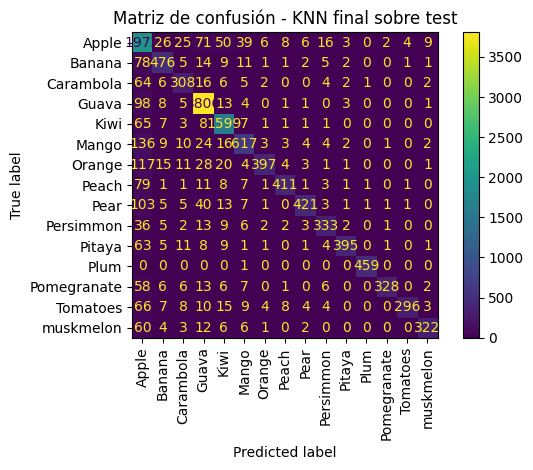


Archivos guardados:
Modelo final: /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/models/knn_k3_euclidean_pca1506.joblib
Métricas finales: /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/outputs/metricas_finales_knn_test.csv
Classification report: /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/outputs/classification_report_knn_test.csv
Matriz de confusión CSV: /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/outputs/matriz_confusion_knn_test.csv
Matriz de confusión imagen: /mnt/c/Users/sebas_formaciones/Pontia_en_local/TFM/outputs/matriz_confusion_knn_test.png


In [10]:
# =========================
# BLOQUE 22C: EVALUACIÓN FINAL DEL MODELO KNN SOBRE TEST
# =========================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import joblib
import time

# Cargamos las matrices PCA desde disco
X_train_pca = np.load(X_TRAIN_PCA_PATH, mmap_mode="r")
X_test_pca = np.load(X_TEST_PCA_PATH, mmap_mode="r")

print("X_train_pca:", X_train_pca.shape)
print("X_test_pca:", X_test_pca.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Mejor valor de k seleccionado en la validación interna
MEJOR_K = 3

# Creamos el modelo final
knn_final = KNeighborsClassifier(
    n_neighbors=MEJOR_K,
    metric="euclidean",
    weights="uniform",
    n_jobs=-1
)

print("\nEntrenando modelo KNN final con k=3...")

inicio_tiempo = time.time()

# Entrenamos con todo el conjunto de entrenamiento
knn_final.fit(X_train_pca, y_train)

print("Modelo entrenado. Realizando predicción sobre test...")

# Predicción sobre el conjunto de prueba
y_pred_test = knn_final.predict(X_test_pca)

tiempo_total = (time.time() - inicio_tiempo) / 60

# Métricas principales
accuracy_test = accuracy_score(y_test, y_pred_test)
f1_macro_test = f1_score(y_test, y_pred_test, average="macro")

print("\nEvaluación final KNN sobre test")
print("Mejor k:", MEJOR_K)
print("Accuracy:", round(accuracy_test, 4))
print("F1 macro:", round(f1_macro_test, 4))
print("Tiempo total:", round(tiempo_total, 2), "min")

# Classification report
print("\nClassification report:")
print(classification_report(y_test, y_pred_test))

# Guardamos el modelo final
KNN_FINAL_PATH = MODELS_DIR / "knn_k3_euclidean_pca1506.joblib"
joblib.dump(knn_final, KNN_FINAL_PATH)

# Guardamos métricas principales
metricas_finales = pd.DataFrame([{
    "modelo": "KNN",
    "k": MEJOR_K,
    "accuracy": accuracy_test,
    "f1_macro": f1_macro_test,
    "tiempo_min": tiempo_total
}])

METRICAS_FINAL_PATH = OUTPUTS_DIR / "metricas_finales_knn_test.csv"
metricas_finales.to_csv(METRICAS_FINAL_PATH, index=False)

# Guardamos classification report en CSV
report_dict = classification_report(y_test, y_pred_test, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

REPORT_PATH = OUTPUTS_DIR / "classification_report_knn_test.csv"
df_report.to_csv(REPORT_PATH)

# Matriz de confusión
clases = np.unique(y_test)

cm = confusion_matrix(y_test, y_pred_test, labels=clases)

df_cm = pd.DataFrame(cm, index=clases, columns=clases)
CM_PATH = OUTPUTS_DIR / "matriz_confusion_knn_test.csv"
df_cm.to_csv(CM_PATH)

# Visualización de matriz de confusión
plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
disp.plot(values_format="d", xticks_rotation=90)
plt.title("Matriz de confusión - KNN final sobre test")
plt.tight_layout()

CM_IMG_PATH = OUTPUTS_DIR / "matriz_confusion_knn_test.png"
plt.savefig(CM_IMG_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("\nArchivos guardados:")
print("Modelo final:", KNN_FINAL_PATH)
print("Métricas finales:", METRICAS_FINAL_PATH)
print("Classification report:", REPORT_PATH)
print("Matriz de confusión CSV:", CM_PATH)
print("Matriz de confusión imagen:", CM_IMG_PATH)

## Interpretación de métricas y resultados del modelo KNN

Tras seleccionar `k=3` mediante validación interna, el modelo KNN final se entrenó con todo el conjunto de entrenamiento y se evaluó sobre el conjunto de prueba.

El conjunto de prueba no fue utilizado durante la selección del hiperparámetro `k`, por lo que los resultados obtenidos representan la evaluación final del modelo.

### Métricas globales del modelo

El modelo obtuvo los siguientes resultados sobre el conjunto de prueba:

- `accuracy`: 0.8604
- `F1 macro`: 0.8401

### Accuracy

El `accuracy` mide el porcentaje total de aciertos del modelo.

En este caso, el modelo obtuvo un `accuracy` de 0.8604, lo que significa que clasificó correctamente aproximadamente el 86,04% de las imágenes del conjunto de prueba.

Esta métrica ofrece una visión general del rendimiento, pero puede ser insuficiente cuando el dataset está desbalanceado, ya que las clases con más imágenes pueden influir más en el resultado global.

### F1 macro

El `F1 macro` calcula el F1-score de cada clase por separado y después realiza una media simple entre todas las clases.

Esto significa que todas las frutas tienen el mismo peso en esta métrica, independientemente de si tienen muchas o pocas imágenes.

En este proyecto es una métrica especialmente importante porque el dataset presenta desbalance entre clases. Por ejemplo, clases como `Guava` y `Apple` tienen muchas más imágenes que otras como `Persimmon`, `Plum` o `muskmelon`.

El modelo obtuvo un `F1 macro` de 0.8401, lo que indica que el rendimiento medio por clase es bueno y relativamente equilibrado.

La diferencia entre `accuracy` y `F1 macro` no es muy elevada:

- `accuracy`: 0.8604
- `F1 macro`: 0.8401

Esto sugiere que el modelo no solo obtiene buenos resultados globales, sino que también mantiene un comportamiento razonable entre las distintas frutas.

### Precision

La `precision` indica, de todas las imágenes que el modelo predijo como una clase concreta, cuántas eran realmente de esa clase.

Dicho de forma sencilla, responde a la pregunta:

> Cuando el modelo dice que una imagen pertenece a una fruta, ¿cuántas veces acierta?

Por ejemplo, la clase `Apple` obtiene una precision de 0.66. Esto significa que, de todas las imágenes que el modelo predijo como Apple, aproximadamente el 66% eran realmente Apple.

Esto indica que el modelo tiende a clasificar como Apple imágenes que realmente pertenecen a otras frutas.

En cambio, `Guava` obtiene una precision de 0.93, lo que indica que cuando el modelo predice Guava, normalmente acierta.

### Recall

El `recall` indica, de todas las imágenes reales de una clase, cuántas consigue detectar correctamente el modelo.

Dicho de forma sencilla, responde a la pregunta:

> De todas las imágenes reales de una fruta, ¿cuántas ha encontrado correctamente el modelo?

Por ejemplo, `Apple` obtiene un recall de 0.88. Esto significa que el modelo detecta correctamente el 88% de las imágenes reales de Apple.

Sin embargo, aunque el recall de Apple es alto, su precision es baja. Esto indica que el modelo encuentra muchas Apple reales, pero también clasifica erróneamente otras frutas como Apple.

En el caso de `Guava`, el recall es de 0.97, lo que indica que el modelo detecta casi todas las imágenes reales de Guava.

### F1-score

El `F1-score` combina `precision` y `recall` en una única métrica.

Es útil porque resume el equilibrio entre ambas. Si una clase tiene buena precision y buen recall, su F1-score será alto. Si una de las dos métricas es baja, el F1-score también se reduce.

Por ejemplo:

- `Guava`: precision 0.93, recall 0.97, F1-score 0.95.
- `Apple`: precision 0.66, recall 0.88, F1-score 0.75.

Esto muestra que Guava tiene un comportamiento más equilibrado y sólido, mientras que Apple presenta más confusión con otras clases.

### Support

El `support` indica cuántas imágenes reales de cada clase hay en el conjunto de prueba.

No mide la calidad del modelo, sino el número de ejemplos disponibles para evaluar cada clase.

Por ejemplo:

- `Guava`: 3940 imágenes.
- `Apple`: 2237 imágenes.
- `Plum`: 460 imágenes.
- `Persimmon`: 414 imágenes.

Este dato ayuda a interpretar las métricas, ya que algunas frutas tienen muchas más imágenes que otras.

### Matriz de confusión

La matriz de confusión permite analizar visualmente los aciertos y errores del modelo.

En la matriz:

- las filas representan la clase real;
- las columnas representan la clase predicha por el modelo;
- la diagonal principal representa los aciertos;
- los valores fuera de la diagonal representan errores de clasificación.

Cuanto mayores sean los valores en la diagonal principal, mejor está clasificando el modelo.

En este caso, se observa una diagonal principal marcada, lo que confirma que el modelo acierta correctamente muchas imágenes de cada clase.

Sin embargo, también se observan errores relevantes hacia la clase `Apple`. Esto significa que varias imágenes reales de otras frutas fueron clasificadas incorrectamente como Apple.

Este comportamiento coincide con el `classification_report`, donde Apple presenta:

- precision: 0.66;
- recall: 0.88;
- F1-score: 0.75.

Es decir, el modelo detecta muchas Apple reales, pero también predice Apple en casos donde la imagen pertenece a otra fruta.

### Casos destacados

El modelo obtiene resultados especialmente buenos en clases como:

- `Guava`, con F1-score de 0.95;
- `Kiwi`, con F1-score de 0.92;
- `Plum`, con F1-score de 1.00;
- `Pitaya`, con F1-score de 0.87;
- `Pomegranate`, con F1-score de 0.86.

Estas clases muestran un rendimiento alto y relativamente estable.

En cambio, algunas clases presentan más dificultad:

- `Apple`, por su baja precision;
- `Orange`, por su recall de 0.66;
- `Pear`, por su recall de 0.70;
- `Tomatoes`, por su recall de 0.68;
- `Carambola`, con un F1-score de 0.75.

Estos casos indican que el modelo no detecta todas las imágenes reales de esas clases con la misma eficacia o que algunas frutas presentan similitudes visuales con otras.

Una posible explicación de las confusiones hacia la clase `Apple` es la variabilidad interna de esta categoría.

La clase Apple contiene imágenes procedentes de distintas subcarpetas, que pueden representar variedades visuales diferentes, por ejemplo en color, forma o condiciones de captura. Esto puede hacer que Apple sea una clase más heterogénea que otras frutas.

Dado que el modelo clásico utiliza descriptores basados en color, forma y textura, frutas visualmente similares, como algunas imágenes de `Tomatoes`, `Orange` o `Pear`, pueden quedar cercanas a Apple en el espacio de características.

Por tanto, la baja precision de Apple podría estar relacionada con que el modelo clasifica como Apple imágenes de otras frutas con características visuales similares. Esta hipótesis debería comprobarse analizando los errores por subcarpeta y revisando ejemplos concretos de imágenes mal clasificadas.


### Conclusión general

El modelo KNN final obtiene un rendimiento positivo para un enfoque clásico de Machine Learning aplicado a imágenes.

Con un `accuracy` de 0.8604 y un `F1 macro` de 0.8401, el modelo demuestra una buena capacidad de clasificación global y un rendimiento razonablemente equilibrado entre clases.

La matriz de confusión y el análisis por clase muestran que el modelo funciona especialmente bien en frutas como `Guava`, `Kiwi` y `Plum`, aunque presenta confusiones relevantes hacia `Apple` y mayores dificultades en clases como `Orange`, `Pear` y `Tomatoes`.

En conjunto, el pipeline clásico basado en RGB, HOG, LBP, StandardScaler, PCA y KNN ofrece un resultado sólido y defendible como modelo de Machine Learning clásico para la clasificación de frutas.